In [19]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
from tqdm.auto import tqdm
from sklearn.datasets import load_wine
from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso, RidgeCV, LassoCV, LogisticRegression
)
from sklearn.preprocessing import StandardScaler
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
)
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings('ignore', category=ConvergenceWarning)
pd.set_option('display.float_format', '{:.4f}'.format)

# Zadanie 1: Regresja liniowa — zbiór WINE

### Wczytanie danych

In [20]:
wine = load_wine(as_frame=True)
df_wine = wine.frame

print(f"Shape: {df_wine.shape}")
print(f"Kolumny: {list(df_wine.columns)}")
df_wine.head(3)

Shape: (178, 14)
Kolumny: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline', 'target']


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.2300,1.7100,2.4300,15.6000,127.0000,2.8000,3.0600,0.2800,2.2900,5.6400,1.0400,3.9200,1065.0000,0
1,13.2000,1.7800,2.1400,11.2000,100.0000,2.6500,2.7600,0.2600,1.2800,4.3800,1.0500,3.4000,1050.0000,0
2,13.1600,2.3600,2.6700,18.6000,101.0000,2.8000,3.2400,0.3000,2.8100,5.6800,1.0300,3.1700,1185.0000,0


In [21]:
df_wine.describe().T


,count,mean,std,min,25%,50%,75%,max
alcohol,178.0000,13.0006,0.8118,11.0300,12.3625,13.0500,13.6775,14.8300
malic_acid,178.0000,2.3363,1.1171,0.7400,1.6025,1.8650,3.0825,5.8000
ash,178.0000,2.3665,0.2743,1.3600,2.2100,2.3600,2.5575,3.2300
alcalinity_of_ash,178.0000,19.4949,3.3396,10.6000,17.2000,19.5000,21.5000,30.0000
magnesium,178.0000,99.7416,14.2825,70.0000,88.0000,98.0000,107.0000,162.0000
total_phenols,178.0000,2.2951,0.6259,0.9800,1.7425,2.3550,2.8000,3.8800
flavanoids,178.0000,2.0293,0.9989,0.3400,1.2050,2.1350,2.8750,5.0800
nonflavanoid_phenols,178.0000,0.3619,0.1245,0.1300,0.2700,0.3400,0.4375,0.6600
proanthocyanins,178.0000,1.5909,0.5724,0.4100,1.2500,1.5550,1.9500,3.5800
color_intensity,178.0000,5.0581,2.3183,1.2800,3.2200,4.6900,6.2000,13.0000


In [22]:
# target: alcohol
target_col = 'alcohol'
feature_cols = [c for c in wine.feature_names if c != target_col]

X_wine = df_wine[feature_cols].values
y_wine = df_wine[target_col].values

print(f"X shape: {X_wine.shape}, y shape: {y_wine.shape}")
print(f"Target '{target_col}' — min: {y_wine.min():.2f}, max: {y_wine.max():.2f}, mean: {y_wine.mean():.2f}")

X shape: (178, 12), y shape: (178,)
Target 'alcohol' — min: 11.03, max: 14.83, mean: 13.00


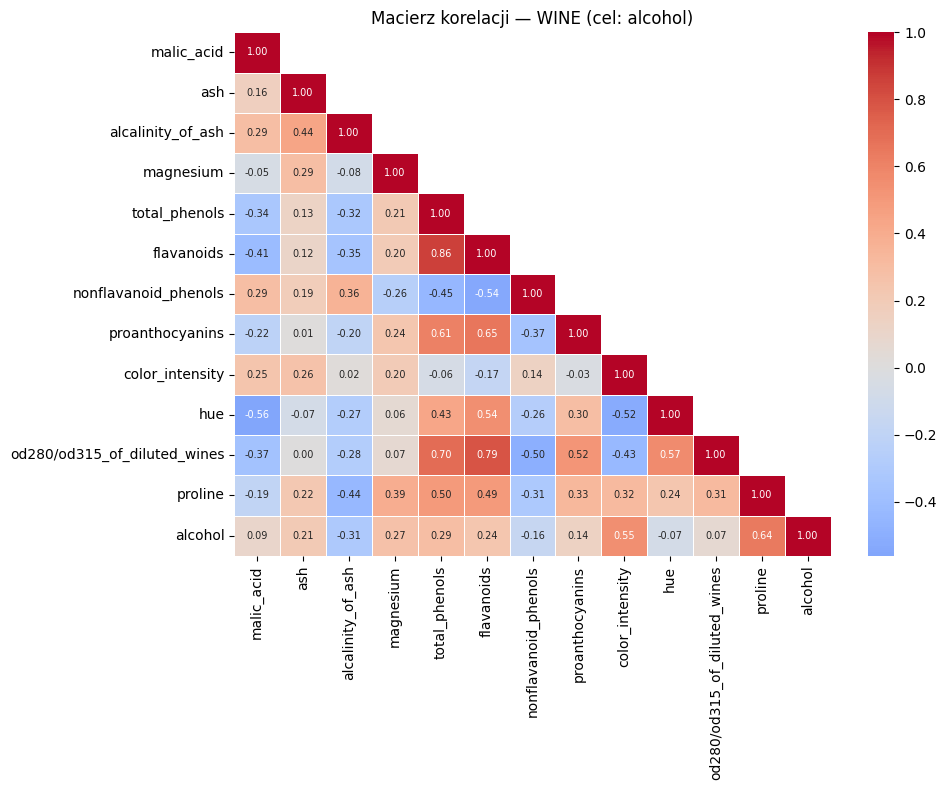

In [23]:
corr = df_wine[feature_cols + [target_col]].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, linewidths=0.4, ax=ax, annot_kws={'size': 7}
)
ax.set_title('Macierz korelacji — WINE (cel: alcohol)', fontsize=12)
plt.tight_layout()
plt.show()

### Podział na train/test

In [24]:
X_wine_train, X_wine_test, y_wine_train, y_wine_test = train_test_split(
    X_wine, y_wine, test_size=0.2
)

print(f"Train: {X_wine_train.shape}, Test: {X_wine_test.shape}")

Train: (142, 12), Test: (36, 12)


### Regresja liniowa (LinearRegression)

In [25]:
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LinearRegression())
])

pipe_lr.fit(X_wine_train, y_wine_train)

y_train_pred = pipe_lr.predict(X_wine_train)
y_test_pred  = pipe_lr.predict(X_wine_test)

print(f"Train — R²: {r2_score(y_wine_train, y_train_pred):.4f}, MSE: {mean_squared_error(y_wine_train, y_train_pred):.4f}")
print(f"Test  — R²: {r2_score(y_wine_test,  y_test_pred):.4f}, MSE: {mean_squared_error(y_wine_test,  y_test_pred):.4f}")

Train — R²: 0.5855, MSE: 0.2673
Test  — R²: 0.4952, MSE: 0.3017


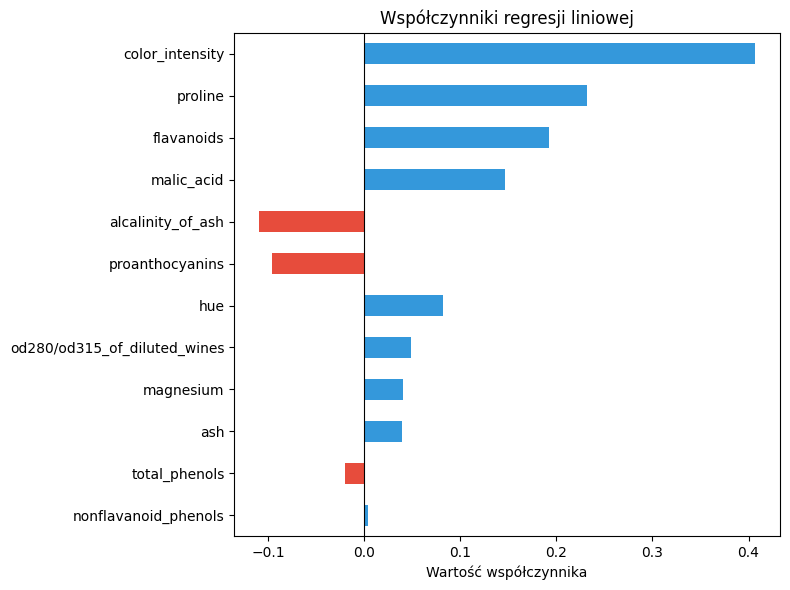

In [26]:
coef_df = pd.Series(lr.coef_, index=feature_cols).sort_values(key=np.abs, ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#e74c3c' if v < 0 else '#3498db' for v in coef_df]
coef_df.plot.barh(ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Współczynniki regresji liniowej')
ax.set_xlabel('Wartość współczynnika')
plt.tight_layout()
plt.show()

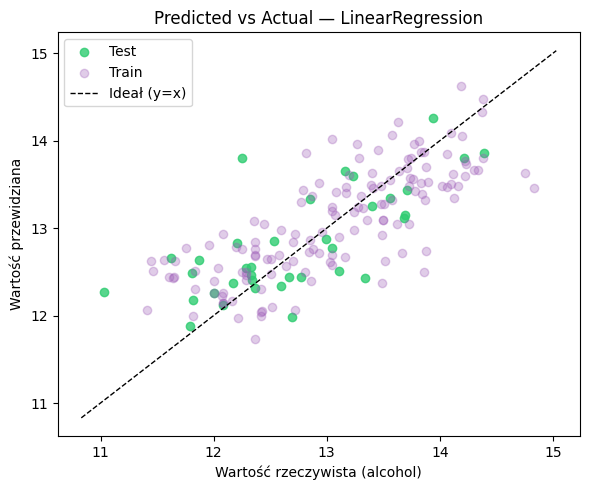

In [28]:
fig, ax = plt.subplots(figsize=(6, 5))

ax.scatter(y_wine_test, y_test_pred, alpha=0.8, color='#2ecc71', label='Test')
ax.scatter(y_wine_train, y_train_pred, alpha=0.3, color='#9b59b6', label='Train')

lims = [min(y_wine.min(), y_test_pred.min()) - 0.2,
        max(y_wine.max(), y_test_pred.max()) + 0.2]
ax.plot(lims, lims, 'k--', linewidth=1, label='Ideał (y=x)')

ax.set_xlabel('Wartość rzeczywista (alcohol)')
ax.set_ylabel('Wartość przewidziana')
ax.set_title('Predicted vs Actual — LinearRegression')
ax.legend()
plt.tight_layout()
plt.show()

### Regularyzacja Ridge i Lasso — ścieżki współczynników

In [31]:
alphas = np.logspace(-3, 5, 100)
ridge_coefs = []
lasso_coefs = []

for alpha in tqdm(alphas, desc='Regularization path'):
    pipe_ridge = Pipeline([('scaler', StandardScaler()), ('model', Ridge(alpha=alpha))])
    pipe_lasso = Pipeline([('scaler', StandardScaler()), ('model', Lasso(alpha=alpha, max_iter=10000))])
    
    pipe_ridge.fit(X_wine_train, y_wine_train)
    pipe_lasso.fit(X_wine_train, y_wine_train)
    
    ridge_coefs.append(pipe_ridge.named_steps['model'].coef_)
    lasso_coefs.append(pipe_lasso.named_steps['model'].coef_)

ridge_coefs = np.array(ridge_coefs)
lasso_coefs = np.array(lasso_coefs)

Regularization path:   0%|          | 0/100 [00:00<?, ?it/s]

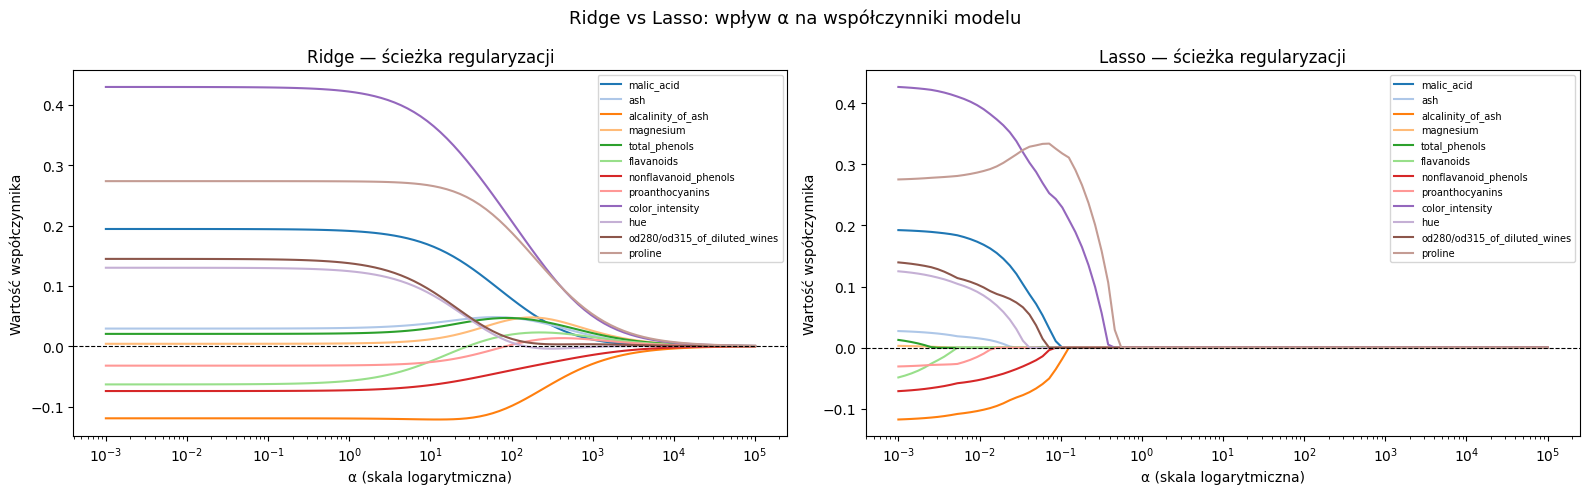

In [34]:
colors = plt.cm.tab20.colors[:len(feature_cols)]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for i, name in enumerate(feature_cols):
    axes[0].plot(alphas, ridge_coefs[:, i], label=name, color=colors[i])
axes[0].set_xscale('log')
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title('Ridge — ścieżka regularyzacji')
axes[0].set_xlabel('α (skala logarytmiczna)')
axes[0].set_ylabel('Wartość współczynnika')
axes[0].legend(fontsize=7, loc='upper right')

for i, name in enumerate(feature_cols):
    axes[1].plot(alphas, lasso_coefs[:, i], label=name, color=colors[i])
axes[1].set_xscale('log')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Lasso — ścieżka regularyzacji')
axes[1].set_xlabel('α (skala logarytmiczna)')
axes[1].set_ylabel('Wartość współczynnika')
axes[1].legend(fontsize=7, loc='upper right')

plt.suptitle('Ridge vs Lasso: wpływ α na współczynniki modelu', fontsize=13)
plt.tight_layout()
plt.show()

### Walidacja krzyżowa dla optymalnego α

In [37]:
ridge_cv = Pipeline([('scaler', StandardScaler()), ('model', RidgeCV(alphas=alphas, scoring='r2', cv=5))])
ridge_cv.fit(X_wine_train, y_wine_train)
alpha_ridge_cv = ridge_cv.named_steps['model'].alpha_

lasso_cv = Pipeline([('scaler', StandardScaler()), ('model', LassoCV(alphas=alphas, cv=5, max_iter=10000))])
lasso_cv.fit(X_wine_train, y_wine_train)
alpha_lasso_cv = lasso_cv.named_steps['model'].alpha_

print(f"Optimal α Ridge (CV):  {alpha_ridge_cv:.4f}")
print(f"Optimal α Lasso (CV):  {alpha_lasso_cv:.4f}")

Optimal α Ridge (CV):  23.1013
Optimal α Lasso (CV):  0.0196


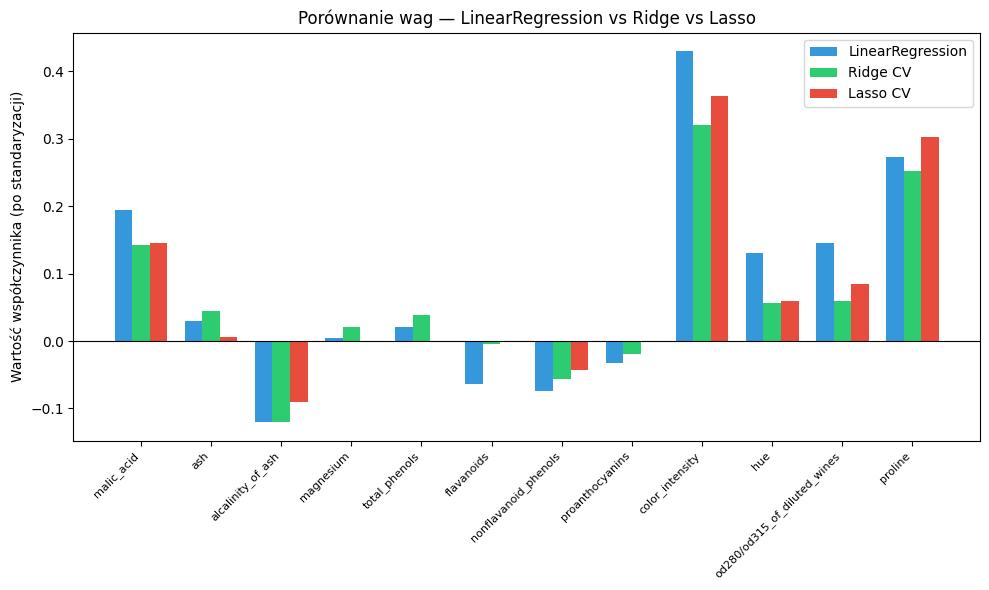

In [39]:
models_coef = {
    'LinearRegression': LinearRegression(),
    'Ridge CV':         Ridge(alpha=alpha_ridge_cv),
    'Lasso CV':         Lasso(alpha=alpha_lasso_cv, max_iter=10000),
}

coef_data = {}
for name, model in models_coef.items():
    pipe = Pipeline([('scaler', StandardScaler()), ('model', model)])
    pipe.fit(X_wine_train, y_wine_train)
    coef_data[name] = pipe.named_steps['model'].coef_

coef_df = pd.DataFrame(coef_data, index=feature_cols)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(feature_cols))
width = 0.25

ax.bar(x - width, coef_df['LinearRegression'], width, label='LinearRegression', color='#3498db')
ax.bar(x,         coef_df['Ridge CV'],         width, label='Ridge CV',         color='#2ecc71')
ax.bar(x + width, coef_df['Lasso CV'],         width, label='Lasso CV',         color='#e74c3c')

ax.set_xticks(x)
ax.set_xticklabels(feature_cols, rotation=45, ha='right', fontsize=8)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Porównanie wag — LinearRegression vs Ridge vs Lasso')
ax.set_ylabel('Wartość współczynnika (po standaryzacji)')
ax.legend()
plt.tight_layout()
plt.show()

### Podsumowanie — Zadanie 1

,R²_train,R²_test,MSE_train,MSE_test
Model,,,,
LinearRegression,0.5855,0.4952,0.2673,0.3017
Ridge(α=1),0.5854,0.4999,0.2673,0.2989
"Ridge(α=23.101, CV)",0.5712,0.5286,0.2765,0.2817
Lasso(α=0.01),0.5820,0.5208,0.2695,0.2864
"Lasso(α=0.0196, CV)",0.5761,0.5343,0.2734,0.2783


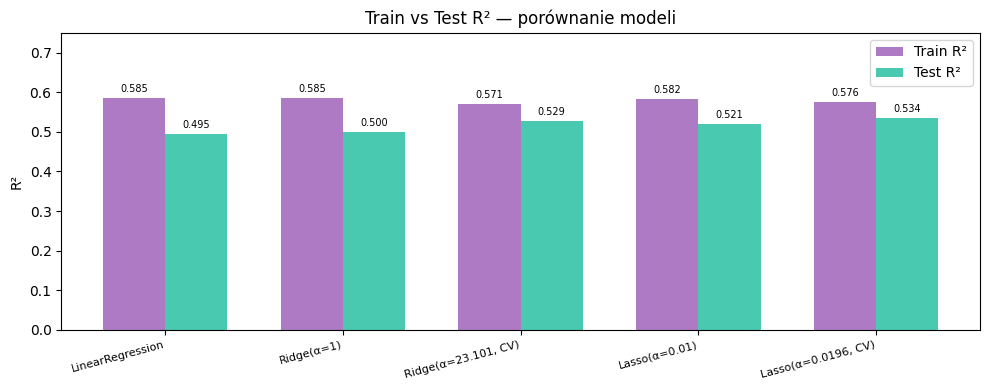

In [41]:
models_reg = [
    ('LinearRegression',                    Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())])),
    ('Ridge(α=1)',                          Pipeline([('scaler', StandardScaler()), ('model', Ridge(alpha=1))])),
    (f'Ridge(α={alpha_ridge_cv:.3f}, CV)', Pipeline([('scaler', StandardScaler()), ('model', Ridge(alpha=alpha_ridge_cv))])),
    ('Lasso(α=0.01)',                       Pipeline([('scaler', StandardScaler()), ('model', Lasso(alpha=0.01, max_iter=10000))])),
    (f'Lasso(α={alpha_lasso_cv:.4f}, CV)', Pipeline([('scaler', StandardScaler()), ('model', Lasso(alpha=alpha_lasso_cv, max_iter=10000))])),
]

rows = []
for name, model in models_reg:
    model.fit(X_wine_train, y_wine_train)
    ytr = model.predict(X_wine_train)
    yte = model.predict(X_wine_test)
    rows.append({
        'Model':     name,
        'R²_train':  r2_score(y_wine_train, ytr),
        'R²_test':   r2_score(y_wine_test, yte),
        'MSE_train': mean_squared_error(y_wine_train, ytr),
        'MSE_test':  mean_squared_error(y_wine_test, yte),
    })

results_df = pd.DataFrame(rows).set_index('Model')
display(results_df.round(4))

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(results_df))
width = 0.35

bars_train = ax.bar(x - width/2, results_df['R²_train'], width, label='Train R²', color='#9b59b6', alpha=0.8)
bars_test  = ax.bar(x + width/2, results_df['R²_test'],  width, label='Test R²',  color='#1abc9c', alpha=0.8)

for bar in bars_train:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)

for bar in bars_test:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(results_df.index, rotation=15, ha='right', fontsize=8)
ax.set_ylabel('R²')
ax.set_title('Train vs Test R² — porównanie modeli')
ax.legend()
ax.set_ylim(0, 0.75)
plt.tight_layout()
plt.show()

---
# Zadanie 2: Klasyfikacja probabilistyczna — zbiór Bankrutów

### Wczytanie danych

In [ ]:
dataset = fetch_ucirepo(id=365)
X_raw = dataset.data.features
y_raw = dataset.data.targets

df = X_raw.copy()
df['class'] = y_raw['class']

print(f"Pełny zbiór: {df.shape}")
print(f"Lata dostępne: {sorted(df['year'].unique())}")

### Preprocessing

In [ ]:
class IQRClipper(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        Q1 = np.percentile(X, 25, axis=0)
        Q3 = np.percentile(X, 75, axis=0)
        IQR = Q3 - Q1
        self.lower_ = Q1 - 1.5 * IQR
        self.upper_ = Q3 + 1.5 * IQR
        return self

    def transform(self, X, y=None):
        return np.clip(X, self.lower_, self.upper_)

In [ ]:
# filtrujemy rok 4, usuwamy A37 (45% braków), wiersze z >7 brakami
df4 = df[df['year'] == 4].drop(columns=['year', 'A37'])
feat_cols = [c for c in df4.columns if c != 'class']
df4 = df4[df4[feat_cols].isnull().sum(axis=1) <= 7].reset_index(drop=True)

X = df4[feat_cols]
y = df4['class']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Po filtracji: {df4.shape}")
print(f"Train: {X_train_raw.shape}, Test: {X_test_raw.shape}")
print(f"Bankruci train: {y_train.sum()} ({100*y_train.mean():.1f}%), test: {y_test.sum()} ({100*y_test.mean():.1f}%)")

In [ ]:
preproc = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('clipper', IQRClipper()),
    ('scaler',  StandardScaler()),
])

X_train_scaled = preproc.fit_transform(X_train_raw)
X_test_scaled  = preproc.transform(X_test_raw)

print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"Mean ≈ 0: {X_train_scaled.mean():.4f}, Std ≈ 1: {X_train_scaled.std():.4f}")

### Regresja logistyczna — baseline

In [ ]:
log_reg = LogisticRegression(C=1, class_weight='balanced', solver='lbfgs', max_iter=2000)
log_reg.fit(X_train_scaled, y_train)
y_pred = log_reg.predict(X_test_scaled)

print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred, zero_division=0):.4f}")
print(f"F1:        {f1_score(y_test, y_pred, zero_division=0):.4f}")

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['OK (0)', 'Bankrut (1)'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Macierz pomyłek — regresja logistyczna (C=1)')
plt.tight_layout()
plt.show()

### Interpretacja wag modelu

In [ ]:
coefs = pd.Series(log_reg.coef_[0], index=feat_cols).sort_values()

top_neg = coefs.head(10)
top_pos = coefs.tail(10).iloc[::-1]
top_features = pd.concat([top_neg, top_pos]).sort_values()

fig, ax = plt.subplots(figsize=(8, 7))
colors = ['#e74c3c' if v < 0 else '#3498db' for v in top_features]
top_features.plot.barh(ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Top 10 cech o największym wpływie na predykcję bankructwa')
ax.set_xlabel('Waga (współczynnik)')
plt.tight_layout()
plt.show()

print(f"Cechy silnie ZWIĘKSZAJĄCE ryzyko bankructwa (wagi +): {list(top_pos.index[:3])}")
print(f"Cechy silnie ZMNIEJSZAJĄCE ryzyko bankructwa (wagi -): {list(top_neg.index[-3:])}")

### Analiza progu klasyfikacji

In [ ]:
y_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]
thresh_results = []

for t in thresholds:
    y_t = (y_proba >= t).astype(int)
    thresh_results.append({
        'Próg': t,
        'Precision': precision_score(y_test, y_t, zero_division=0),
        'Recall':    recall_score(y_test, y_t, zero_division=0),
        'F1':        f1_score(y_test, y_t, zero_division=0),
    })

df_thresh = pd.DataFrame(thresh_results).set_index('Próg')
print(df_thresh.round(4))

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_thresh.plot(ax=axes[0], marker='o')
axes[0].set_title('Precision / Recall / F1 vs próg klasyfikacji')
axes[0].set_xlabel('Próg')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1.05)
axes[0].legend()

fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='#3498db', label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=0.8)
axes[1].set_title('Krzywa ROC')
axes[1].set_xlabel('FPR (False Positive Rate)')
axes[1].set_ylabel('TPR (True Positive Rate / Recall)')
axes[1].legend()

plt.tight_layout()
plt.show()

### Wpływ parametru C na jakość modelu

In [ ]:
C_values = [0.001, 0.01, 0.1, 1, 10, 100]
c_results = []

for C in tqdm(C_values, desc='C sweep'):
    m = LogisticRegression(C=C, class_weight='balanced', solver='lbfgs', max_iter=2000)
    m.fit(X_train_scaled, y_train)
    yp = m.predict(X_test_scaled)
    c_results.append({
        'C':        C,
        'Precision': precision_score(y_test, yp, zero_division=0),
        'Recall':    recall_score(y_test, yp, zero_division=0),
        'F1':        f1_score(y_test, yp, zero_division=0),
    })

df_c = pd.DataFrame(c_results).set_index('C')
print(df_c.round(4))

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
df_c.plot(ax=ax, marker='o')
ax.set_xscale('log')
ax.set_title('Wpływ parametru C na metryki (regresja logistyczna)')
ax.set_xlabel('C (skala logarytmiczna)')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.legend()
plt.tight_layout()
plt.show()

print("Małe C → silna regularyzacja (duże α), uproszczony model.")
print("Duże C → słaba regularyzacja, model bardziej dopasowany do danych treningowych.")

### Ridge vs Lasso — porównanie regularyzacji

In [ ]:
penalties = [
    ('Ridge (L2, C=1)',    LogisticRegression(C=1,          class_weight='balanced', solver='saga', max_iter=5000)),
    ('Ridge (L2, C=0.1)',  LogisticRegression(C=0.1,        class_weight='balanced', solver='saga', max_iter=5000)),
    ('Lasso (L1, C=1)',    LogisticRegression(C=1,   l1_ratio=1, class_weight='balanced', solver='saga', max_iter=5000)),
    ('Lasso (L1, C=0.1)',  LogisticRegression(C=0.1, l1_ratio=1, class_weight='balanced', solver='saga', max_iter=5000)),
]

pen_results = []
for name, model in tqdm(penalties, desc='Ridge vs Lasso'):
    model.fit(X_train_scaled, y_train)
    yp = model.predict(X_test_scaled)
    n_zero = np.sum(np.abs(model.coef_[0]) < 1e-4)
    pen_results.append({
        'Model':        name,
        'Precision':    precision_score(y_test, yp, zero_division=0),
        'Recall':       recall_score(y_test, yp, zero_division=0),
        'F1':           f1_score(y_test, yp, zero_division=0),
        'Wagi ≈ 0':     int(n_zero),
        'Wagi aktywne': int(len(feat_cols) - n_zero),
    })

df_pen = pd.DataFrame(pen_results).set_index('Model')
df_pen

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_pen[['Precision', 'Recall', 'F1']].plot.bar(ax=axes[0], color=['#3498db', '#e67e22', '#2ecc71'], alpha=0.85)
axes[0].set_title('Metryki: Ridge vs Lasso')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1.05)
axes[0].tick_params(axis='x', rotation=20)
axes[0].legend()
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.3f}',
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontsize=7)

df_pen[['Wagi ≈ 0', 'Wagi aktywne']].plot.bar(ax=axes[1], color=['#e74c3c', '#95a5a6'], alpha=0.85)
axes[1].set_title('Sparseness wag: Ridge vs Lasso')
axes[1].set_ylabel('Liczba cech')
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend()
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontsize=8)

plt.suptitle('Porównanie regularyzacji L1 (Lasso) vs L2 (Ridge)', fontsize=13)
plt.tight_layout()
plt.show()

print("Lasso (L1) zeruje wagi mniej ważnych cech — efekt selekcji cech.")
print("Ridge (L2) redukuje wagi, ale nie zeruje — wszystkie cechy pozostają.")